<a href="https://colab.research.google.com/github/kithik7/Theoretical_Neuroscience/blob/Ex4_Supervised_Learning/TNS_II_Exercise_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised learning

Supervised learning is a form of learning which relies on the presence of a ”teacher” who knows the right answers. In the context of neural networks (NN), the learning comprises changing in synaptic weights.


When our NN wants to learn something, there are 2 phases to this - the training phase and the testing phase. In the former, the teacher provides the input-output mapping so that the projection weights can be set according to the observed covariance between preand postsynaptic activity. Once fixed, the projection weights are able to reproduce the
input- output mapping without the teacher - we can test the performance in the latter phase. The exercise illustrates supervised learning with an artificial (non-biological) example: the transformation of cartesian to polar coordinates.

\\

<div align=center>
<img width=750 src="https://drive.google.com/uc?id=1UJ-V_XBTRJvCHwgxgbvvX6CGeqGVlrlY"/>
</div>


## Cartesian representation

Visual position in Cartesian coordinates $(x,y)$ is represented by an `input' population of $N_{xy}$ neurons.  Each neuron $i$ has a Gaussian receptive field centred on $(x_i, y_i)$ and of width $\sigma_\mathit{xy}=2$.  It's average response $f_i(x,y)$ to a stimulus at $(x,y)$ is

$$
f_i\left( x ,  y \right) = R_\mathit{max} \exp{\left(-\frac{(x_i - x)^2}{2 \, \sigma_\mathit{xy}^2 } \right)}  \,\exp{\left(-\frac{(y_i - y)^2}{2 \, \sigma_\mathit{xy}^2 } \right)}
$$

Acute responses $R_i^\mathit{xy}$ also include input-dependent noise $\eta_i$,  which is Gaussian distributed with mean zero and variance equal to the average response, $\sigma^2_i = f_i(x,y)$:  
$$
R_i^\mathit{xy}  = f\left( x, y\right)+ \eta_i, \qquad\qquad \eta_i=\mathrm{normrnd}(0,\mathrm{sqrt}(f_i))
$$

Choose $N_{xy}=100$ and scatter the preferred positions $(x_i,y_i)$ of input neurons randomly in the range $[-10, +10]$!

**Make sure that the whole space is properly covered.**



## Polar representation

Visual position in polar coordinates $r,\theta$ is represented by two separate `output' populations of $N_r$ and $N_\theta$ neurons, respectively. These neurons have Gaussian receptive fields centred on $\log r$ and $\theta$, respectively, with tuning widths $\sigma_r=\log_{10} 2$ and $\sigma_\theta = \pi/6$, respectively:

$$
g_j\left( \theta\right) = R_{max} \exp\left[-\frac{\left( \theta_j -
\theta \right)^2}{2  \sigma_{\theta}^2}\right], \qquad\qquad\qquad\qquad R_j^{\theta} = g_j\left( \theta\right) + \eta_j
$$
\
$$
h_k\left(\log_{10} r \right) =   R_{max} \, \exp\left[-\frac{\left(\log_{10} r / r_k \right)^2}{2 \, \sigma_r^2}\right] + \eta_k, \qquad\qquad R_k^r  = h_k\left(\log_{10} r \right) + \eta_k
$$
\
where $\eta_j$ and $\eta_k$ are independent Gaussian noise with mean zero and variance equal to the average response, $\sigma_j^2= g_j(\theta)$ and $\sigma_k^2=h_k(r)$, respectively:
$$
\eta_j=\mathrm{normrnd}(0,\mathrm{sqrt}(g_j)), \qquad\qquad \eta_k=\mathrm{normrnd}(0,\mathrm{sqrt}(h_k))
$$

Choose $N_r=N_\theta=30$ and scatter the preferred positions of output neurons randomly in the ranges of $\theta_j\in[-\pi,\pi]$ and $\log_k r \in{-1,1}$.

**Make sure that the whole space is properly covered.**

Additionally, try the natural logarithm instead of the base-10 one.

## Activity Level Comparison

For this task, generate two neurons whose preferred positions are $[-5, 5]$ and $[5, 5]$ in the
cartesian space, respectively. Then, generate inputs within the range of $x=[-10, 10]$ with
$0.01$ increments, and $y=5$. Now, calculate the responses of these two neurons to all inputs and plot the activities as a function of x in a single figure to observe the changes in the  activity levels.

## Training phase

Generate several thousand stimuli with random positions $(x,y)\in[-10, +10]$ in cartesian coordinates and  $(r,\theta)$ in polar coordinates, where $r=\sqrt{x^2+y^2}$ and $\theta = \arctan{ y/ x}$.  Compute $r,\theta$ with the provided function `cart2pol()`$.


Compute the direct responses $R_i^{xy}(x,y)$ of input neurons, as well as the direct responses $R_j^\theta(\theta)$ and $R_k^r(r)$ of output neurons, as detailed in the two preceding sections.


Next compute the covariance for each input-output pair of neurons $ji$, as well as for each input-output pair $ki$, and collect the values into the covariance matrices $C_{ji}$ and $C_{ki}$.   You can do this numerically by averaging over all input-output responses in your training ensemble:

\
$$
C_{ji} = \langle R_j^\theta \, R_i^{xy}\rangle - \langle R_j^\theta \rangle \, \langle R_i^{xy} \rangle \\
\\
C_{ki} = \langle R_k^r \, R_i^{xy}\rangle - \langle R_k^r \rangle \, \langle R_i^{xy} \rangle \\
$$
\
where $\langle \rangle$ stands for the ensemble average.

\


## Testing phase

Create feedforward projections from input  to  output neurons by setting projections weights $w_{ji}$ (from cartesian neuron $i$ to radius neuron $j$) and $w_{ki}$ (from cartesian neuron $i$ to angle neuron $k$) to

$$
w_{ji} = W \cdot C_{ji}, \qquad\qquad w_{ki} = W \cdot C_{ki}
$$
where $W$ is a global scale factor.


Now use this projection to drive the output populations {\it indirectly}, i.e., via the feedforward projection.  To this end, generate output activities as a (rectified) sum of input activities, as follows:

$$
T_j^\theta = \left[ \sum_i \, w_{ji} \, R_i^{xy}(x,y) \right]_+ \\
\\
T_k^r = \left[ \sum_i \, w_{ki} \, R_i^{xy}(x,y) \right]_+ \\
$$


Specifically, generate stimuli at random positions  $(x,y)\in[-10, +10]$ and compute both the direct responses $R_i^{xy}(x,y)$, $R_j^\theta(\theta)$, and $R_k^r(r)$, as well as the indirect responses $T_j(x,y)$.


Assess how well the feedforward projection performs the coordinate transform by generating two `scatter plots' of direct against indirect responses --   $R_j^\theta(\theta)$ against $T_j^\theta(x,y)$, and  $R_k^r(r)$ against $T_k^\theta(x,y)$ -- and by computing the correlation coeffcient!


Choose the value of global scaling factor $W$ such as to maximise the correlation!

## Decoding the System


How informative about stimulus position are the output populations?  To answer this question, *decode* the output activity by computing the response-weighted
average of the preferred angles $\theta_j$ and radii $r_k$:

\\


$$
\theta_{inferred} = \frac{\sum_j \, R_j^\theta \, \theta_j}{\sum_j \, R_j^\theta}\\
\\
\log r_{inferred} = \frac{\sum_k \, R_k^r \, \log r_k}{\sum_k \, R_k^r}\\
$$

\\

Plot actual versus decoded (i.e., inferred) stimulus positions for your test ensemble? How does the result depend on the size of input and output populations?

## Optional
Change $R_{max}$ to a greatly smaller and greatly larger value compared to initial value. Then,
once again plot the actual vs. inferred values. What happens to the system performances
and why? Explain!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def cart2pol(x, y):
    r = np.hypot(x, y)  # Equivalent to sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)  # Computes angle in radians
    return theta, r

FileNotFoundError: [Errno 2] No such file or directory: 'ex4_supervised_learning/pref_positions_scatter_check_100,2.png'

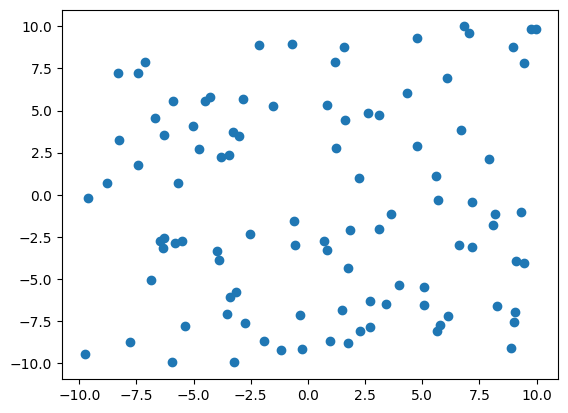

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#task A
# choose Nxy = 100 and scatter pref positions [xi , yi] in the range [-10 , +10]. make sure whole
#space is covered

#for this use np.random.rand that takes shape as argument and not range
#shape of this grid is , 100 rows of neurons and 2 columns with xi and yi. therefore
#we use standard linear transformation formula to map variable U to any desired interval
#position = U * (b-a ie target width) + a : where a is the shift factor ie target minimum
#therefore 20-10


pref_positions = np.random.uniform(-10 , +10 , size=(100,2))
size_pref_pos = "100,2"
plt.scatter(pref_positions[:,0] , pref_positions [:,1])
plt.savefig(f'ex4_supervised_learning/pref_positions_scatter_check_{size_pref_pos}.png') #f before location, forward slash only after
plt.close()


#setting pref positions of polar population, j and k with theta output and log10r output

pref_pos_theta = np.random.uniform(-np.pi , np.pi , 30) #no size parameter here because its just difference between stim angle and
#pref angle, unlike cart population, it doesnt have x and y coodinate because its not on a distance scale. its a ratio on the scale:
#-pi and +pi
#fixed: was being scaled twice by multiplying by 2*pi - pi after already using uniform(-pi, pi)
plt.scatter(pref_pos_theta, np.zeros_like(pref_pos_theta) , marker = '+')
plt.xlabel('theta')
plt.savefig(f'ex4_supervised_learning/pref_positions_scatter_check_theta.png')
#and this is a single number that conveys rotation along a circle so you dont use the size parameter here
pref_pos_r = np.random.uniform(-1, 1, 30) #30 values between -1 and +1 in log10 scale

plt.scatter(pref_pos_r, np.zeros_like(pref_pos_r) , marker = '+')
plt.xlabel('log10(r)')
plt.savefig(f'ex4_supervised_learning/pref_positions_scatter_check_r.png')

pref_pos_r_ln = np.random.uniform(-np.log(10) , np.log(10) , 30)
plt.scatter(pref_pos_r_ln, np.zeros_like(pref_pos_r_ln) , marker = '+')
plt.xlabel('natural log r log(r)')
plt.savefig(f'ex4_supervised_learning/pref_positions_scatter_check_ln(r).png')

#task 1 - activity level comparison
#assign two pref positions for cartesian neurons at -5,5 and +5,5 and i would expect two bell shaped curves
#that meet at the irigin and trail off, we use the response function to show this
#tuning width is sigma_xy = 2, Rmax isnt explicitly set so im gonna set it to 2

#setup
R_max = 1
sigma_xy = 2
pref_N1 = (-5,5)
pref_N2 = (5,5) #parentheses here because it cannot be changed whereas square brackets are for lists that grow continuously

#define stimulus range [-10,+10] with increments of 0.01 which is basically the x axis
#computer cannot compute an infinite range of numbers between two numbers, 0.01 increments would make my curve smooth and not jagged
x = np.arange(-10,10 , 0.01) #creates array of evenly spaces values with step values
#np.arange snytax (start at 10, stop at 10, at a step of 0.01) always use parentheses

y = 5
#gaussian response function = f(xiyi) = Rmax exp( - (xi-x))² + (yi-y)²/2sigma²xy

squared_distance_N1 = (pref_N1[0]-x)**2 + (pref_N1[1]-y)**2
response_N1 = R_max * np.exp(-squared_distance_N1 / (2 * sigma_xy**2))
squared_distance_N2 = (pref_N2[0]-x)**2 + (pref_N2[1]-y)**2
response_N2= R_max * np.exp(-squared_distance_N2 / (2 * sigma_xy**2))

#plotting activity level comparison in one image

#step 1 : set the stage

fig,ax = plt.subplots(figsize=(8,4))
ax.plot( x , response_N1 , color = 'cadetblue', label = 'Neuron 1 (Pref: -5,5)')
ax.plot(-5, 1, 'o', color='cadetblue', markersize=8, label='pref N1') #mark this point with a dot

ax.plot( x , response_N2 , color = 'steelblue', label = 'Neuron 2 (Pref:  5,5)')
ax.plot(5, 1, 'o', color='cadetblue', markersize=8, label='pref N2') #mark this point with a dot

ax.set_xlabel('x')
ax.set_ylabel('response')
ax.set_title('activity level comparison')
ax.legend()
plt.savefig('ex4_supervised_learning/activity_level_comparison.png')
plt.close()

#training phase
#covariance = Cji = <rjtheta - rixy> - <rj_theta> * <rixy>

stim = np.random.uniform(-10 , 10 , (5000,2))  #min max, size = several 1000 rows of x and y coordinates
print(stim.shape)

# the function cart2pol that was given to us
def cart2pol(x, y):
    r = np.hypot(x, y)  # Equivalent to sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)  # Computes angle in radians
    return theta, r


theta_stim , r_stim = cart2pol(stim[:,0], stim[:,1])
print(theta_stim.shape)
print(r_stim.shape)

#3 populations and 3 responses cart = 100, theta = 30 and r = 30, fixed positions with 5000 stimuli w cooridnates
#scattered b/w -10 and +10



#compute response functions
#tuning widths for sd r=log102 and sd θ=π/6, poipulations)
R_max = 1
sigma_xy= 2 #tuning width = how broad the response is
R_xy = np.zeros((5000,100)) #storage array
for i in range(100):
   xi = pref_positions[i,0] #pref x of neuron 1
   yi = pref_positions[i,1] #pref y of neuron 1

   x_stim = stim[:,0] #all of stim x values : means all rows and 0 is set of x coord values from column 0
   y_stim = stim[:,1]

   f = R_max *np.exp (-(xi-x_stim)**2/(2*sigma_xy**2)) * np.exp(-(yi-y_stim)**2/(2*sigma_xy**2))

   R_xy[:,i] = f
print(R_xy.shape)
#now we add noise to obtain acute responses R_i_xy where the mean = 0, std = sqrt(f_i) and has the shame shape as R_xy naturally

acute_R_xy = R_xy + np.random.normal(0 , np.sqrt(R_xy) , (5000, 100)) #np.random.normal always takes size argument (r,c) within parentheses as a tuple

print(acute_R_xy.shape)


R_theta = np.zeros((5000,30)) #to create an empty container before loop starts
R_max = 1
sigma_theta = np.pi/6

for i in range(30):
  theta_i = pref_pos_theta[i] #i is the current neurons index, theta_i picks out just one neuron's preferred angle
  theta_stim = theta_stim
  f = R_max * np.exp(-(theta_i - theta_stim)**2 / (2*sigma_theta**2))
  R_theta[:, i] = f

print(R_theta.shape)


#computing responses for r log population
R_rlog = np.zeros((5000,30))
R_max =1
sigma_r = np.log10(2)
r_stim_log = np.log10(r_stim) #fixed: was using np.log (natural log) but sigma_r and pref_pos_r use log10 - must be consistent
for i in range(30):
  r_i = pref_pos_r[i]

  f = R_max * np.exp(-((r_i) - (r_stim_log))**2 / (2*sigma_r**2))
  R_rlog[:, i] = f

print(R_rlog.shape)

#adding noise to both theta and r populations
acute_R_theta = R_theta + np.random.normal(0 , np.sqrt(R_theta) , (5000,30))
acute_R_rlog = R_rlog + np.random.normal(0 , np.sqrt(R_rlog) , (5000,30))

print(acute_R_theta.shape)
print(acute_R_rlog.shape)

#compute covariance

#two covariance matrices with input cartesian population with shapes (30,100)
""" R_theta_J has shape (5000,30), the rows are stimuli amd columns are neurons. Averaging across rows means averaging
 across 5000 stimuli - this axis is 0. I want one average value
per neuron, so i average overall all stimuli for each neuron separately.
this means that for each column, each neuron, i add up all 5000 rows and divide by 5000.
I am collapsing the rows down into a single numberper column.

Collapsing rows = collapsing axis 0
the result is a 1d array of 30 values - one per neuron. The 5000 stimuli dimension disappears and collapses into one average value.
Collapsing columns"""

# mean responses across all 5000 stimuli
mean_R_xy = np.mean(acute_R_xy, axis=0)      # shape (100,)
mean_R_theta = np.mean(acute_R_theta, axis=0) # shape (30,)
mean_R_rlog = np.mean(acute_R_rlog, axis=0)   # shape (30,)


# covariance: <R_j * R_i> - <R_j><R_i>
# acute_R_theta shape (5000,30), acute_R_xy shape (5000,100)
# matrix multiply transposed theta by xy gives (30,100)

C_theta = (acute_R_theta.T @ acute_R_xy) / 5000 - np.outer(mean_R_theta, mean_R_xy) #transpose - col become rows and rows become col

C_rlog = (acute_R_rlog.T @ acute_R_xy) / 5000 - np.outer(mean_R_rlog, mean_R_xy)

print(C_theta.shape)  # should be (30, 100)
print(C_rlog.shape)   # should be (30, 100)

# set weights equal to covariance — fixed: w_theta and w_rlog were never defined
W = 1.07
w_theta = W * C_theta  # shape (30, 100)
w_rlog = W * C_rlog    # shape (30, 100)


#TESTING PHASE

#generate brand new test stimuli coordinates (1000 trials, 2 columns)
num_test=1000
w = 1.0
w_theta = w * C_theta  # shape (30, 100)
w_rlog = w * C_rlog    # shape (30, 100)
stim_test = np.random.uniform(-10 , 10, size=(1000,2))

theta_test, r_test = cart2pol(stim_test[:,0] , stim_test[:,1])

#convert radius to log scale because R_rlog needs it — use log10 to match training
log_r_test = np.log10(r_test)

#compute direct responses for test data
R_xy_test = np.zeros((num_test, 100))
R_theta_test = np.zeros((num_test, 30))
R_rlog_test = np.zeros((num_test, 30))

#fill in test responses like training loop
for i in range(100):
    xi = pref_positions[i, 0]
    yi = pref_positions[i, 1]
    f = R_max * np.exp(-(xi - stim_test[:, 0])**2 / (2 * sigma_xy**2)) * np.exp(-(yi - stim_test[:, 1])**2 / (2 * sigma_xy**2))
    R_xy_test[:, i] = f  # Target columns, just like before


for i in range(30):
    theta_i = pref_pos_theta[i]
    d_theta = np.arctan2(np.sin(theta_i - theta_test), np.cos(theta_i - theta_test))
    f = R_max * np.exp(-d_theta**2 / (2 * sigma_theta**2))
    R_theta_test[:, i] = f

for i in range(30):
    r_i = pref_pos_r_ln[i]
    f = R_max * np.exp(-(r_i - log_r_test)**2 / (2 * sigma_r**2))
    R_rlog_test[:, i] = f


# set weights equal to covariance ; passing raw covariance values directly into weights without altering scale

#indirect responses

#weights C_theta have shape 30,100
#r_xy_test input has shape 1000,100
#have to transpose to multiply with C theta


T_theta = np.maximum(0,(w_theta @ R_xy_test.T).T) #has shape ((1000,30)
T_rlog = np.maximum(0, (w_rlog @ R_xy_test.T).T) #has shape (1000,30)




# acute r theta transpose puts all 30 theta neurons into rows downwards [30,5000]
# acute_R_xy keeps all 100 cartesian neurons in columns going across n[5000,100]
#at points where they cross, theyre paired systematically
#weights = knot to make neurons fire, if weight is 0, input neuron can fire but output doesnt comprehend it
#if weight is negative, connection is inhibitory, input neuron actively supresses output, for high weigts (+1.5) it forces
#output neuron to fire too (multiplies, or becomes loud). when weight is 1, signal passed through the output neuron, unchanged.

#coordinate (-5,5) sits at 135° angle


"""
whats happening here?
so a random point (-5,5) ends up in the upper left quadrant of a cartesian plane
my cart neuron 5  checks this and say - yes, I like this. it lights up like a christmas tree

but we also have polar neurons (that live in the polar express, sorry couldnt help meself),  simultaneously
(-5,5) is translated into theta = arctan y/x using cart2pol. it calculates that (-5,5) is at an angle of 135° geometrically

the 30 theta neurons check this angle, and because polar neuron 2 prefers 135 degrees and also lights up

the covariance matrices, check if this happens beyond chance. both these neurons lighting up are brought together by a matrix
(acuteRtheta @ acute Rxy). cartesian neuron 5 and polar neuron 2 always fire at this instance, whenever a stim lands in this
upper left zone, their covariance calculation is postive

we take this covariance matrix and declare :W_Theta = 1.0*c_THETA , THIS IS A SYNAPTIC WEIGHT that connects cart neuron 5 to
polar neuron 2 (like a nice long telephone wire), for neurons that dont fire together, covariance is 0, no wire is built hence.

Analogy: the weight allowed polar neurons to see stim indirectly,
the signal = activity x weight , when neurons sees this in its zone, it screams into the phone at a volume of 1.0db for example
if that lookout has a heavy wire connecting to a specific polar neuron, the weight is 1.5

result = electrical signal of 1.0 x 1.5 = 1.5 units are sent into polar neurons mailbox

moreover, if cov during training for neuron 5 and neuron 2 was 0.85, it's just a value sitting, by setting w_theta = 1.0*C_theta
I take that static stastical number and assign it as the connection strength of the telephone wire betwen the two neurons.


"""


"""

Testing phase

now that their weight is 0.85, it dictates how strongly signal is relayed during testing
when new stim appears cart 5 maybe fires at an activity level of 2.0 (R_xy)

and cart 5 sees it and fires at activity level 2, signal travels down wire and hits covariance defined weight

signal = activity * weight = 2x0.85 = 1.70
because covariance value 0.85 was loaded into weight, it acts as a filter where it allows 85% of input activity to multiply and
move forward into output neurons pool

The test
drop a new random test point
take 100 input neurons
and push them through matrix multiplication
raw signal input = w_theta @r_xy_test
np.maxmimum(0..) = ceiling ,
T_theta arrives , output neurons add up all the charges from 100 of these wires and final sum is the indirect response matrix
"""

#DECODING THE SYSTEM

sum_T_theta = np.sum(T_theta, axis=1) # Collapse columns (Axis 1) to get sum per stimulus
sum_T_rlog = np.sum(T_rlog, axis=1)
sum_T_theta[sum_T_theta == 0] = 1e-6
sum_T_rlog[sum_T_rlog == 0] = 1e-6

# Multiply across rows normally
theta_inferred = np.sum(T_theta * pref_pos_theta, axis=1) / sum_T_theta
log_r_inferred = np.sum(T_rlog * pref_pos_r_ln, axis=1) / sum_T_rlog

#plotting
"""
Plot actual versus decoded (i.e., inferred) stimulus positions for your test ensemble?
How does the result depend on the size of input and output populations?
Optional

Change Rmax to a greatly smaller and greatly larger value compared to initial value.
Then, once again plot the actual vs. inferred values. What happens to the system performances and why? Explain!

"""

# DECODING
# sum all theta neuron responses per stimulus — collapse 30 columns into one number
# axis=1 means collapse columns — one total per row (per stimulus)
sum_T_theta = np.sum(T_theta, axis=1)  # shape (1000,)
sum_T_rlog = np.sum(T_rlog, axis=1)    # shape (1000,)

# avoid division by zero — if no neuron fires at all, denominator becomes tiny value
sum_T_theta[sum_T_theta == 0] = 1e-6
sum_T_rlog[sum_T_rlog == 0] = 1e-6

# population vector decode — response weighted average
# T_theta * pref_pos_theta scales each neuron's preferred angle by how strongly it fired
# np.sum(..., axis=1) adds up all 30 neurons' weighted votes per stimulus
# dividing by sum_T_theta normalises so all votes sum to 1
theta_inferred = np.sum(T_theta * pref_pos_theta, axis=1) / sum_T_theta  # shape (1000,)
log_r_inferred = np.sum(T_rlog * pref_pos_r, axis=1) / sum_T_rlog        # shape (1000,)

# PLOTTING — decoded vs true
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# theta plot — true theta on x axis, decoded theta on y axis
# if network learned well, points should fall along the diagonal
ax1.scatter(theta_test, theta_inferred, color='cadetblue', alpha=0.5, s=12)
ax1.plot([-np.pi, np.pi], [-np.pi, np.pi], color='crimson', linestyle='--', label='Perfect decoding')
ax1.set_xlabel('True theta (radians)')
ax1.set_ylabel('Decoded theta (radians)')
ax1.set_title('Theta decoding — true vs decoded')
ax1.legend()

# radius plot — true log10(r) on x axis, decoded log10(r) on y axis
ax2.scatter(np.log10(r_test), log_r_inferred, color='steelblue', alpha=0.5, s=12)
ax2.plot([-1, 1], [-1, 1], color='crimson', linestyle='--', label='Perfect decoding')
ax2.set_xlabel('True log10(r)')
ax2.set_ylabel('Decoded log10(r)')
ax2.set_title('Radius decoding — true vs decoded')
ax2.legend()

plt.tight_layout()
plt.savefig('ex4_supervised_learning/decoding_results.png')
plt.close()



